In [281]:
# import warnings
# warnings.filterwarnings('ignore')

In [282]:
import os
import pprint
import tempfile

from typing import Dict, Text

import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

import tensorflow_recommenders as tfrs

In [ ]:
# 텐서보드를 위해 로그폴더 만들기.
# import datetime

# log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [284]:
# Load Dataset
ratings = tfds.load("movielens/100k-ratings", split="train")
movies = tfds.load("movielens/100k-movies", split="train")

In [285]:
for x in ratings.take(1).as_numpy_iterator():
    pprint.pprint(x)

{'bucketized_user_age': 45.0,
 'movie_genres': array([7]),
 'movie_id': b'357',
 'movie_title': b"One Flew Over the Cuckoo's Nest (1975)",
 'raw_user_age': 46.0,
 'timestamp': 879024327,
 'user_gender': True,
 'user_id': b'138',
 'user_occupation_label': 4,
 'user_occupation_text': b'doctor',
 'user_rating': 4.0,
 'user_zip_code': b'53211'}


2026-03-10 14:35:41.083355: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [286]:
for x in movies.take(1).as_numpy_iterator():
    pprint.pprint(x)

{'movie_genres': array([4]),
 'movie_id': b'1681',
 'movie_title': b'You So Crazy (1994)'}


2026-03-10 14:35:41.142187: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [287]:
# user_id 및 movie_title 만
ratings = ratings.map(lambda x: {
    "movie_title": x["movie_title"],
    "user_id": x["user_id"],
})

movies = movies.map(lambda x: x["movie_title"])

In [288]:
print(len(ratings))
print(len(movies))

100000
1682


In [289]:
# Train/ Test 분할
# ~~~~~~~~~~~~~SIX SEVEN~~~~~~~~~~~~~~~~~~~~~~~
tf.random.set_seed(67)
shuffled = ratings.shuffle(len(ratings), seed=67, reshuffle_each_iteration=False)

train = shuffled.take(80_000)
test = shuffled.skip(80_000).take(20_000)

In [290]:
print(len(train))
print(len(test))

80000
20000


---

데이터에 있는 고유한 사용자ID와 영화제목도 알아봅시다.

이는 범주형 기능(숫자 데이터가 아닌 글자 데이터)의 원시 값을 모델의 임베딩 벡터에 매핑할 수 있어야 하기 때문에 중요합니다.

그렇게 하려면 인접한 범위의 정수로 매핑하는 어휘가 필요합니다. 이를 통해 임베딩 테이블에서 임베딩을 조회할 수 있습니다.

In [291]:
# 중복제거
movie_titles = movies.batch(1_000)
user_ids = ratings.batch(1_000_000).map(lambda x: x["user_id"])

unique_movie_titles = np.unique(np.concatenate(list(movie_titles)))
unique_user_ids = np.unique(np.concatenate(list(user_ids)))

unique_movie_titles[:10]

array([b"'Til There Was You (1997)", b'1-900 (1994)',
       b'101 Dalmatians (1996)', b'12 Angry Men (1957)', b'187 (1997)',
       b'2 Days in the Valley (1996)',
       b'20,000 Leagues Under the Sea (1954)',
       b'2001: A Space Odyssey (1968)',
       b'3 Ninjas: High Noon At Mega Mountain (1998)',
       b'39 Steps, The (1935)'], dtype=object)

모델 구현

---

모델의 아키텍처를 설정하는 것은 모델링의 핵심 부분입니다.

2개의 타워 검색 모델을 구축하기 때문에 각 타워를 개별적으로 구축한 다음 최종 모델에서 결합할 수 있습니다.

1.쿼리 타워
2. 후보 타워

In [292]:
# 쿼리 타워
# --- 쿼리 및 후보 표현의 차원을 결정하기
embedding_dimension = 32 # 값이 높을수록 더 정확한 모델에 해당하지만 과적합된다.

# --- 모델 자체를 정의하기
user_model = tf.keras.Sequential([
    tf.keras.layers.StringLookup(
        vocabulary=unique_user_ids, mask_token=None),
    tf.keras.layers.Embedding(len(unique_user_ids)+1, embedding_dimension)
])

In [293]:
# 후보 타워
movie_model = tf.keras.Sequential([
    tf.keras.layers.StringLookup(
        vocabulary=unique_movie_titles, mask_token=None),
    tf.keras.layers.Embedding(len(unique_movie_titles)+1, embedding_dimension)
])

힘내! <img src="https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FlcYNc%2Fbtq5L5jjbUT%2FAAAAAAAAAAAAAAAAAAAAAMqPmfOUGWqgvCH_iRsie_8of1JJWOMQJNgy1PqmSwzM%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DI6BAEoY9N93st8ouY50bu2CKFOM%253D" width="50%">

---

**tfrs.metrics.FactorizedTopK*** 메트릭사용.

- 상황: 유저1이 '토이스토리'를 봤음.

- 모델: 유저1은 '주토피아'가 1위고 '토이스토리'는 500위? (틀림)

- task의 반응: 벌점 100점! 유저1과 토이스토리 임베딩수를 서로 비슷하게 수정하삼!

- 결과: 모델이 숫자를 고쳐서 다음번에는 '토이스토리'를 10위 안으로 올리게 됨.ㅎㅎ

In [294]:
# 측정 항목
metrics = tfrs.metrics.FactorizedTopK(
    candidates=movies.batch(128).map(movie_model) 
    # 유니크하게바뀐걸 넣어주는 게 정석인데 넘파이계열이라 ㄴㄴ 데이터셋을넣어야함
    # 영화 다 넣어서 32개숫자보따리(임베딩)로 바꿔놓으삼 --> 정답후보지
    # TopK의 역할: (훈련 중) 후보뽑아서 최소 K등 안에는 정답이 있나 체크 -> 너무못하면 loss크게줌.(아래)
)

# 손실(Loss)
task = tfrs.tasks.Retrieval(
    metrics=metrics
    # Retrieval의 역할: 정답 오답 구별/ 손실 계산-반환
    # 이를 사용해서 모델의 훈련 루프를 구현
)

| 데이터 소스 | 데이터 항목 | 사용되는 곳 |
| :--- | :--- | :--- |
| Ranting Dataset | user_id | user_model |
| Ranting Dataset | movie_title | movie_model |
| Movie Dataset | movie_title | metrics의 candidates |

- tfrs.Model 기본 클래스는 단순히 편리한 클래스임. (아우~ 추상적이야)
- tfrs.Model을 상속받음으로써 얻는 효과: 파편화된 쿼리/ 후보 타워/ Task를 하나로 합치기 위해~
- 표준 tf.keras.Model은 이런 모델 두 개 동시에 처리하는 복잡한 계산(유저랑 영화를 각각 임베딩해서 비교하기) 못해
- tfrs.Model 상속 받기만 하면 compute_loss함수를 모델이 '아이게 내 *공부방식*이군아'라고 알아먹음.

---

- 대조학습 (*공부방식*)

정답 데이터(P): 유저1이 '토이스토리'봤으면 두 임베딩 수가 서로 달라붙음 (내적점수를 높임)

오답 데이터(N): 유저1이 안 본 수천개의 다른 영화들은 -> 그 숫자들과는 서로 밀어냄. (내적 점수를 낮춤)

**평범하게쓸줄도알아야합니다.**

In [295]:
# 전체 모델
class MovielensModel(tfrs.Model):
    def __init__(self, user_model, movie_model):
        super().__init__()
        self.movie_model: tf.keras.Model = movie_model
        self.user_model: tf.keras.Model = user_model
        self.task: tf.keras.layers.Layer = task
    
    
    # 모델이 한 번 공부할 때마다 이 함수를 실행해서 반성문 작성함.
    def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor: 
        # -> 결과값으로 tf.Tensor형태의 숫자를 뱉어내겠다는 약속
        user_embeddings = self.user_model(features["user_id"])
        positive_movie_embeddings = self.movie_model(features["movie_title"])
        
        return self.task(user_embeddings, positive_movie_embeddings) # 두 변수 받아 점수내리기

# 평범하게~...
# tf.keras.Model과 override, train_step, test_step

class NoBaseClassMovielensModel(tf.keras.Model):
    def __init__(self, user_model, movie_model):
        super().__init__()
        # : 이건설명표
        # = 이건 실제 물건을 칸에 집어넣기.
        self.movie_model: tf.keras.Model = movie_model
        self.user_model: tf.keras.Model = user_model
        self.task: tf.keras.layers.Layer = task
        
    def train_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:
        with tf.GradientTape() as tape: 
            # 학습 중 아래에서 일어나는 계산 과정을 tape에 기록해두었다가 나중에 기울기를 계산하는 기능. (미분값)
            # 내가 임베딩 숫자 하나를 살짝 올리면, Loss는 얼마나 줄어들까를 계산하고 싶은 것.
            
            # 손실 계산
            user_embeddings = self.user_model(features["user_id"])
            positive_movie_embeddings = self.movie_model(features["movie_title"])
            loss = self.task(user_embeddings, positive_movie_embeddings)
            
            # 정규화 손실 계산 (과적합 방지(외우는 거 방지))
            # 너무 외우는 거 같으면 벌금을 매김.
            regularization_loss = sum(self.losses) # tf은 각 층(유저모델, 영화모델..)에서 발생한 벌금들을 self.losses에 모아둠.
            
            # 최종 벌점. 
            # 더하는 이유: 모델에게 두 가지 목표를 동시에 주기 위해서임. (loss:공부점수/ regularization loss:태도점수)
            # (모델은 이제 이 total loss를 줄이기 위해 임베딩 숫자들을 고치기 시작.)
            total_loss = loss + regularization_loss
            
        # 얼마나 고쳐야할지 계산-분석 하기.
        gradients = tape.gradient(total_loss, self.trainable_variables) # 녹화분기울기분석(목표, 고칠부품들) (고칠부품들은 32개의 임베딩 수임.)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
        # 계산한대로 숫자고치기(apply gradients).
        # (수정 지시서, 수정할 나사들), zip으로 묶은 것은 A번나사에는 A수정지시서를, B번나사에는 B지시서를.. 짝맞추는 역할.
        
        metrics = {metric.name: metric.result() for metric in self.metrics}
        # {} 이거로 씌워진 건 딕셔너리
        # 이름: 점수 (시험점수만들어있는데 loss..등 벌점칸도 만들기.)
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        
        return metrics # 최종 명단
        
        
    # 시험: 얼마나 모델이 잘하는지 확인만 하는 단계이다.
    def test_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:
        # 손실 계산
        user_embeddings = self.user_model(features["user_id"])
        positive_movie_embeddings = self.movie_model(features["movie_title"])
        loss = self.task(user_embeddings, positive_movie_embeddings)
        
        regularization_loss = sum(self.losses)
        
        total_loss = loss + regularization_loss
        
        # ---
        
        metrics = {metrics.name: metrics.result() for metrics in self.metrics}
        metrics["loss"] = loss
        metrics["regularizatiion_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        
        return metrics

---

- **피팅 및 평가**

In [296]:
model = MovielensModel(user_model, movie_model) # 먼저 모델을 인스턴스화(설계도(class)대로 진짜 물건을 하나 찍어내겟단뜻.)
# MovielensModel()호출, 모델들 부품 챙기삼.

model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.1))
# learning rate : 한 번 공부할 때(batch) 마다 얼마나 숫자를 크게 바꿀지 정하는 수치.
# batch size=10 -->  한 번에 10개씩 공부한다는듯.

In [297]:
# train/ test 데이터를 섞고 캐시
cached_train = train.shuffle(100_000).batch(8192).cache()
cached_test = test.batch(4096).cache()
# 에포크가 시작될 때 마다 데이터를 랜덤하게 섞기.

In [ ]:
training_recode = model.fit(cached_train,
                            epochs=3,
                            #callbacks=[tensorboard_callback]
                            )

Epoch 1/3
10/10 [==============================] - 7s 574ms/step - factorized_top_k/top_1_categorical_accuracy: 7.5000e-04 - factorized_top_k/top_5_categorical_accuracy: 0.0064 - factorized_top_k/top_10_categorical_accuracy: 0.0163 - factorized_top_k/top_50_categorical_accuracy: 0.0944 - factorized_top_k/top_100_categorical_accuracy: 0.1705 - loss: 69858.0305 - regularization_loss: 0.0000e+00 - total_loss: 69858.0305
Epoch 2/3
10/10 [==============================] - 5s 490ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0021 - factorized_top_k/top_5_categorical_accuracy: 0.0151 - factorized_top_k/top_10_categorical_accuracy: 0.0323 - factorized_top_k/top_50_categorical_accuracy: 0.1568 - factorized_top_k/top_100_categorical_accuracy: 0.2808 - loss: 67501.0256 - regularization_loss: 0.0000e+00 - total_loss: 67501.0256
Epoch 3/3
10/10 [==============================] - 5s 478ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0024 - factorized_top_k/top_5_categorical_accura

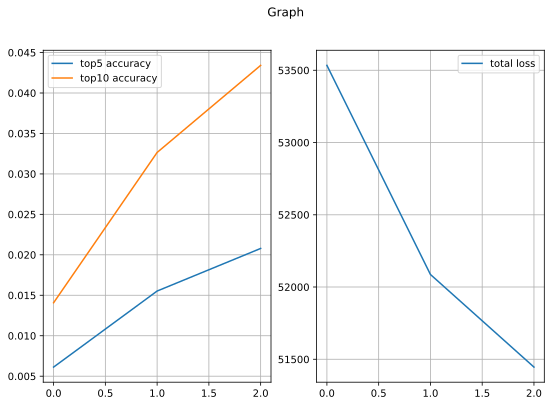

In [ ]:
# 학습 곡선 시각화 (Matplotlib)
fig, axes = plt.subplots(ncols=2, figsize=(9,6))
fig.suptitle("Graph")
for idx, ax in enumerate(axes):
    ax.grid()
    if idx == 0:
        # ax.plot(training_recode.history["factorized_top_k/top_1_categorical_accuracy"], label="top1 accuracy")
        ax.plot(training_recode.history["factorized_top_k/top_5_categorical_accuracy"], label="top5 accuracy")
        ax.plot(training_recode.history["factorized_top_k/top_10_categorical_accuracy"], label="top10 accuracy")
        # ax.plot(training_recode.history["factorized_top_k/top_50_categorical_accuracy"], label="top50 accuracy")
        # ax.plot(training_recode.history["factorized_top_k/top_100_categorical_accuracy"], label="top100 accuracy")
    else:
        ax.plot(training_recode.history["total_loss"], label="total loss")
        # ax.plot(training_recode.history["loss"], label="loss")
        # ax.plot(training_recode.history["regularization_loss"], label="regualrization loss")
    ax.legend()
plt.show()

- **TensorBoard 사용해보기**

In [ ]:
# 학습곡선 시각화 (TensorBoard) (처음파일생성할때)
# %reload_ext tensorboard
# %tensorboard --logdir logs
# !pkill tensorboard

# --- (기존 파일읽을때)
# %tensorboard --logdir logs/fit

In [ ]:
# 마지막 모델 테스트
model.evaluate(cached_test, return_dict=True)

5/5 [==============================] - 4s 403ms/step - factorized_top_k/top_1_categorical_accuracy: 3.5000e-04 - factorized_top_k/top_5_categorical_accuracy: 0.0043 - factorized_top_k/top_10_categorical_accuracy: 0.0127 - factorized_top_k/top_50_categorical_accuracy: 0.1025 - factorized_top_k/top_100_categorical_accuracy: 0.2104 - loss: 31226.1491 - regularization_loss: 0.0000e+00 - total_loss: 31226.1491


{'factorized_top_k/top_1_categorical_accuracy': 0.0003499999875202775,
 'factorized_top_k/top_5_categorical_accuracy': 0.0042500002309679985,
 'factorized_top_k/top_10_categorical_accuracy': 0.01269999984651804,
 'factorized_top_k/top_50_categorical_accuracy': 0.10254999995231628,
 'factorized_top_k/top_100_categorical_accuracy': 0.21044999361038208,
 'loss': 28375.36328125,
 'regularization_loss': 0.0,
 'total_loss': 28375.36328125}

test set성능은 train성능보다 훨씬 나쁘다. 다음 두 가지 요인때문입니다.

1. 과적합
2. 사용자가 이미 본 영화중 일부를 다시 추천하고 있어, 새로운 영화가 순위권 밖으로 밀리고 있다.

해결방법?: 봤던 영화는 추천에서 빼기.(추후)

---

In [327]:
# 예측하기 (tfrs.layers.factorized_top_k.BruteForce)

index = tfrs.layers.factorized_top_k.BruteForce(model.user_model) # BruteForce: 전체영화하나하나 다 뒤져서 제일 점수 높은 걸 찾겠다.
# 유저모델 넣는 이유는 유저 번호를 받아서 임베딩 숫자로 변환하는 도구를요구함.

index.index_from_dataset( # index_from_dataset 메서드역할: 영화제목들을 임베딩숫자로 싹바꿔서 비교할준비를마침.
    tf.data.Dataset.zip((movies.batch(100), movies.batch(100).map(model.movie_model)))
    # 데이터셋으로 (영화제목과 임베딩 숫자를 딱..붙여서.)
    # 텐서플로전용 zip은 인자 하나만 받게 설계됨(튜플로만)
)

_, titles = index(tf.constant(["42"])) # 기계는 "추천점수"와"영화제목" 두개 주는데 점수관심없으니 언더바로 버린다는뜻.
print(f"유저67이 좋아할만한 영화세개: {titles[0, :3]}") 

유저67이 좋아할만한 영화세개: [b'Houseguest (1994)' b'While You Were Sleeping (1995)'
 b'Fried Green Tomatoes (1991)']


---

# Model Serving
: **실제 앱에서 유저가 접속했을 때 실시간으로 추천 영화를 내놓게 함.** (학습 후 배포 방법)

위를 구현하려면 1. 쿼리모델 2.ANN인덱스(Candidate Model) 이 두가지가 결합되어야함.

(TFRS는 이 두개를 하나의 패키지로 묶어서 내보내게 해줌.)

In [328]:
with tempfile.TemporaryDirectory() as tmp: # with:들여쓰기동안에만 대여하겠다. # 일회용 폴더만들겜. 폴더이름은 tmp
    path = os.path.join(tmp, "model") # join이 중간에 슬래시 넣어줌.
    # 패스는 전체주소되다..
    
    tf.saved_model.save(index, path) # 위에서 인덱스는 실전서빙용이된 완제품임.(model은 걍 공부만한상태임.)
    
    loaded = tf.saved_model.load(path)
    
    scores, titles = loaded(["42"])
    
    print(f"추천: {titles[0][:3]}")


INFO:tensorflow:Assets written to: /var/folders/c5/cl6djkjd0b3g6dptld67qj4r0000gn/T/tmpxklnf54g/model/assets


INFO:tensorflow:Assets written to: /var/folders/c5/cl6djkjd0b3g6dptld67qj4r0000gn/T/tmpxklnf54g/model/assets


추천: [b'Houseguest (1994)' b'While You Were Sleeping (1995)'
 b'Fried Green Tomatoes (1991)']


- BruteForce: 하나하나 다 대조(노가다)
- **ScaNN**: 미리 비슷한 것끼리 그룹화(속도빨라짐) --> 큰데이터셋!유리 (근데살짝 정확도가 떨어짐.)

((ScaNN은 리눅스에게 친절하다. 아래코드는 코랩사용하도록!))

In [ ]:
scann_index = tfrs.layers.factorized_top_k.ScaNN(model.user_model)
scann_index.index_from_dataset(
    tf.data.Dataset.zip((movies.batch(100), movies.batch(100).map(model.movie_model))) #맥의비애
)

_, titles = scann_index(tf.constant(["42"]))
print(f"42에게 추천: {titles[0, :3]}")

In [ ]:
with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, "model")
    
    tf.saved_model.save(
        index, #근데 scann_index를 저장해야하지않나;;
        path,
        options=tf.saved_model.SaveOptions(namespace_whitelist=["Scann"]) #외부인(Scann)출입 허가 즉, 허용목록에 Scann이라는 이름을 등록하겠다라는 뜻.
    )
    loaded = tf.saved_model.load(path)
    scores, titles = loaded(["42"])
    print(f"추천: {titles[0][:3]}")